In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import pandas as pd#特征工程
import numpy as np#矩阵运算
import matplotlib.pyplot as plt#画图
import matplotlib.image as mpimg#画图
import seaborn as sns#Seaborn其实是在matplotlib的基础上进行了更高级的API封装，从而使得作图更加容易，在大多数情况下使用seaborn就能做出很具有吸引力的图，而使用matplotlib就能制作具有更多特色的图。应该把Seaborn视为matplotlib的补充，而不是替代物。
%matplotlib inline
#不用调用plt.imshow也能直接展示图片

np.random.seed(2)#设置随机种子

from sklearn.model_selection import train_test_split#分割训练集、测试集的方法
from sklearn.metrics import confusion_matrix#混淆矩阵 

import itertools

from keras.utils import to_categorical #转换到独热编码，将类别向量转换为二进制（只有0和1）的矩阵类型表示，一位有效位编码


from keras.models import Sequential#

from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D#神经网络层

from keras.optimizers import RMSprop#一种优化方法


from tensorflow.keras.preprocessing.image import ImageDataGenerator#数据增强
#https://blog.csdn.net/jacke121/article/details/79245732

from keras.callbacks import ReduceLROnPlateau#
#回调函数，在训练时使用。当评价指标不再提升时，减少学习率


sns.set(style='white', context='notebook', palette='deep')#画图设置

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
import tensorflow as tf
# tf.config.experimental.set_memory_growth(tf.config.list_physical_devices('GPU')[0], True)

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

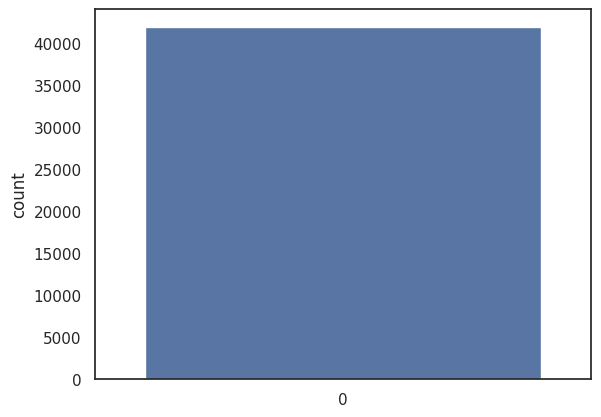

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
Y_train = train["label"]#得到训练集标签

# Drop 'label' column
X_train = train.drop(labels = ["label"],axis = 1) #得到训练集特征列

# free some space
del train #删除train变量

g = sns.countplot(Y_train)#画图，统计数量

Y_train.value_counts()#计算每个值的数量

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
# Normalize the data
X_train = X_train / 255.0
test = test / 255.0

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
# 黑白图  图片只有一个通道 长宽 都是 28 个像素
X_train = X_train.values.reshape(-1,28,28,1)
test = test.values.reshape(-1,28,28,1)

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# Encode labels to one hot vectors (ex : 2 -> [0,0,1,0,0,0,0,0,0,0])把标签编码为独热向量形式
Y_train = to_categorical(Y_train, num_classes = 10)

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
random_seed = 2
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size = 0.1, random_state=random_seed)

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
'''
- filters：滤波器的数量，即输出的通道数；
- kernelsize：卷积核的大小，这里是一个5x5的矩阵；
- padding：卷积的方式，这里使用'Same'表示输出图像的大小与输入图像相同；
- activation：激活函数，这里使用'Relu'函数；
- inputshape：输入数据的形状，这里是一个28x28的灰度图像（深度为1）。
'''

import keras
model = keras.models.Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)),
])
print(X_train[0].shape)
p = model.predict(X_train[0:3])
p.shape

(28, 28, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


(3, 28, 28, 32)

In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
# Set the CNN model 
# my CNN architechture is（我的CNN架构是） In -> [[Conv2D->relu]*2 -> MaxPool2D -> Dropout]*2 -> Flatten -> Dense -> Dropout -> Out

model = Sequential()

#in -> [Conv2D->relu]*2 -> MaxPool2D -> Dropout] ->
# input batch size ,28,28,1
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu', input_shape = (28,28,1)))
# batch size ,28,28,32
model.add(Conv2D(filters = 32, kernel_size = (5,5),padding = 'Same', 
                 activation ='relu'))
# batch size ,28,28,32
model.add(MaxPool2D(pool_size=(2,2)))
# batch size ,14,14,32

model.add(Dropout(0.25))
#-> [Conv2D->relu]*2 -> MaxPool2D -> Dropout] ->
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))

# batch size ,14,14,64
model.add(Conv2D(filters = 64, kernel_size = (3,3),padding = 'Same', 
                 activation ='relu'))
# batch size ,14,14,64

model.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))
# batch size ,7,7,64

model.add(Dropout(0.25))

#-> Flatten -> Dense -> Dropout -> Out
model.add(Flatten())
# batch size ,3136

model.add(Dense(256, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))

In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
# Define the optimizer定义优化器
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08, decay=0.0)
'''
“decay=0”是RMSprop优化算法的一个参数，它控制了学习率的衰减。
具体来说，在RMSprop算法中，每个权重参数都有自己的学习率
，而decay参数会使这个学习率随着时间的推移而逐渐变小。
但是，由于decay=0，因此该算法不会在训练过程中降低学习率。

“epsilon=1e-08”是RMSprop优化算法的一个参数，它是用来防止除零错误的一个小量，通常取极小的值（例如1e-8）。
在RMSprop算法中，计算梯度平方平均值时需要对平方梯度加上一个极小的值，以避免出现除以零的错误。

“rho=0.9”是一种优化算法的参数，用于控制梯度的平滑度。具体来说，该参数决定了在计算平方梯度的指数移动平均值时，
历史数据的重要性。较高的rho值可以使平均值对历史数据的依赖性更强，从而使整个优化过程更加稳定。
'''

/usr/local/lib/python3.10/dist-packages/keras/src/optimizers/base_optimizer.py:33: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


'\n“decay=0”是RMSprop优化算法的一个参数，它控制了学习率的衰减。\n具体来说，在RMSprop算法中，每个权重参数都有自己的学习率\n，而decay参数会使这个学习率随着时间的推移而逐渐变小。\n但是，由于decay=0，因此该算法不会在训练过程中降低学习率。\n\n“epsilon=1e-08”是RMSprop优化算法的一个参数，它是用来防止除零错误的一个小量，通常取极小的值（例如1e-8）。\n在RMSprop算法中，计算梯度平方平均值时需要对平方梯度加上一个极小的值，以避免出现除以零的错误。\n\n“rho=0.9”是一种优化算法的参数，用于控制梯度的平滑度。具体来说，该参数决定了在计算平方梯度的指数移动平均值时，\n历史数据的重要性。较高的rho值可以使平均值对历史数据的依赖性更强，从而使整个优化过程更加稳定。\n'

In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
# Compile the model 装配模型用于训练
model.compile(optimizer = optimizer , loss = "categorical_crossentropy", metrics=["accuracy"])

In [13]:
# --- [CELL 12]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 13}
# === BEFORE (original) ===
# # Set a learning rate annealer定义学习率退火算法。定义回调函数，在训练时，相应的回调函数的方法就会被在各自的阶段被调用。
# # https://keras.io/zh/callbacks/
# # https://keras.io/zh/callbacks/#reducelronplateau
# learning_rate_reduction = ReduceLROnPlateau(monitor='val_acc', 
#                                             patience=3, 
#                                             verbose=1, 
#                                             factor=0.5, 
#                                             min_lr=0.00001)
# '''
# 
# 在您提供的代码中，learningratereduction是ReduceLROnPlateau回调函数的一个实例，用于在模型训练过程中动态地减小学习率。
# 具体来说，它监视了验证集的准确性（即'monitor'='valacc'），并且如果在3个时期内没有改进，
# 则减小学习率（即'patience'=3）。该调用还指定了减小因子（即'factor'=0.5）和最小学习率（即'minlr'=0.00001），
# 以便在执行减少操作时进行限制，从而保持学习率的稳定性和有效性。如果您想要更好地了解ReduceLROnPlateau的工作原理和参数设置，
# 
# verbose是ReduceLROnPlateau回调函数的一个可选参数，用于控制输出详细程度的标志。
# 如果verbose=1，则在执行时期减少操作时将输出一条消息，以指示学习率的更新和当前的状态。
# 如果verbose=0，则不会输出任何消息。通常情况下，verbose的默认值为0，因为它可以大大减少输出的噪声和干扰。
# 如果您需要更详细的输出和信息，可以将verbose的值设置为1或更高
# 可以查看Keras文档：https://keras.io/callbacks/#reducelronplateau。
# '''

# === AFTER (edited) ===
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)
'''

在您提供的代码中，learningratereduction是ReduceLROnPlateau回调函数的一个实例，用于在模型训练过程中动态地减小学习率。
具体来说，它监视了验证集的准确性（即'monitor'='valacc'），并且如果在3个时期内没有改进，
则减小学习率（即'patience'=3）。该调用还指定了减小因子（即'factor'=0.5）和最小学习率（即'minlr'=0.00001），
以便在执行减少操作时进行限制，从而保持学习率的稳定性和有效性。如果您想要更好地了解ReduceLROnPlateau的工作原理和参数设置，

verbose是ReduceLROnPlateau回调函数的一个可选参数，用于控制输出详细程度的标志。
如果verbose=1，则在执行时期减少操作时将输出一条消息，以指示学习率的更新和当前的状态。
如果verbose=0，则不会输出任何消息。通常情况下，verbose的默认值为0，因为它可以大大减少输出的噪声和干扰。
如果您需要更详细的输出和信息，可以将verbose的值设置为1或更高
可以查看Keras文档：https://keras.io/callbacks/#reducelronplateau。
'''

"\n\n在您提供的代码中，learningratereduction是ReduceLROnPlateau回调函数的一个实例，用于在模型训练过程中动态地减小学习率。\n具体来说，它监视了验证集的准确性（即'monitor'='valacc'），并且如果在3个时期内没有改进，\n则减小学习率（即'patience'=3）。该调用还指定了减小因子（即'factor'=0.5）和最小学习率（即'minlr'=0.00001），\n以便在执行减少操作时进行限制，从而保持学习率的稳定性和有效性。如果您想要更好地了解ReduceLROnPlateau的工作原理和参数设置，\n\nverbose是ReduceLROnPlateau回调函数的一个可选参数，用于控制输出详细程度的标志。\n如果verbose=1，则在执行时期减少操作时将输出一条消息，以指示学习率的更新和当前的状态。\n如果verbose=0，则不会输出任何消息。通常情况下，verbose的默认值为0，因为它可以大大减少输出的噪声和干扰。\n如果您需要更详细的输出和信息，可以将verbose的值设置为1或更高\n可以查看Keras文档：https://keras.io/callbacks/#reducelronplateau。\n"

In [14]:
# --- [CELL 13]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 14}
# === BEFORE (original) ===
# # 定义一个ModelCheckpoint回调函数，用于保存验证集上准确率最高的模型
# checkpoint_filepath = 'best_model.keras'
# model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
#     filepath=checkpoint_filepath,
#     monitor='val_acc',
#     mode='max',
#     save_best_only=True)

# === AFTER (edited) ===
checkpoint_filepath = 'best_model.keras'
model_checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True)

In [15]:
# --- [CELL 14]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 15}
epochs = 1 #30 # Turn epochs to 30 to get 0.9967 accuracy
batch_size = 86

In [16]:
# --- [CELL 15]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 16}
datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        #featurewise_center：布尔值，使输入数据集去中心化（均值为0）, 按feature执行。
        #samplewise_center：布尔值，使输入数据的每个样本均值为0。
        #featurewise_std_normalization：布尔值，将输入除以数据集的标准差以完成标准化, 按feature执行。
        #samplewise_std_normalization：布尔值，将输入的每个样本除以其自身的标准差。

        zca_whitening=False,  # apply ZCA whitening布尔值，对输入数据施加ZCA白化
        rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)整数，数据提升时图片随机转动的角度。随机选择图片的角度，是一个0~180的度数，取值为0~180。在 [0, 指定角度] 范围内进行随机角度旋转
        zoom_range = 0.1, # Randomly zoom image 浮点数或形如[lower,upper]的列表，随机缩放的幅度，若为浮点数，则相当于[lower,upper] = [1 - zoom_range, 1+zoom_range]。用来进行随机的放大。
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        #height_shift_range和width_shift_range是用来指定水平和竖直方向随机移动的程度，这是两个0~1之间的比例。
        horizontal_flip=False,  # randomly flip images
        vertical_flip=False)  # randomly flip images
        #horizontal_flip：布尔值，进行随机水平翻转。随机的对图片进行水平翻转，这个参数适用于水平翻转不影响图片语义的时候。
        #vertical_flip：布尔值，进行随机竖直翻转。


datagen.fit(X_train)

In [17]:
# --- [CELL 16]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 17}
# stepsperepoch是一个fitgenerator()函数的参数，它用于指定每个训练周期（epoch）的训练步骤数。
# 具体来说，它是由训练集的大小（即Xtrain.shape[0]）和批量大小（即batchsize）相除得出的结果。
# 这个参数告诉模型在每个训练周期中要从训练数据集中取出多少个批次（batch）进行训练。
# 这是因为，在使用生成器（如ImageDataGenerator）生成数据时，我们无法确定生成的数据集的大小和数量。
# 因此，使用stepsperepoch参数可以确保我们在训练时使用的数据集总大小是相同的
history = model.fit(datagen.flow(X_train,Y_train, batch_size=batch_size),
                              epochs = epochs, validation_data = (X_val,Y_val),
                              verbose = 2, steps_per_epoch=X_train.shape[0] // batch_size
                              , callbacks=[learning_rate_reduction,model_checkpoint_callback])

/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


439/439 - 25s - 56ms/step - accuracy: 0.8679 - loss: 0.4133 - val_accuracy: 0.9762 - val_loss: 0.0725 - learning_rate: 0.0010


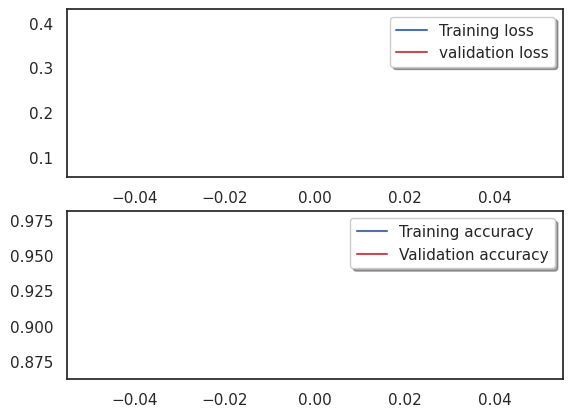

In [18]:
# --- [CELL 17]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 18}
# === BEFORE (original) ===
# fig, ax = plt.subplots(2,1)
# ax[0].plot(history.history['loss'], color='b', label="Training loss")
# ax[0].plot(history.history['val_loss'], color='r', label="validation loss",axes =ax[0])
# legend = ax[0].legend(loc='best', shadow=True)
# 
# ax[1].plot(history.history['acc'], color='b', label="Training accuracy")
# ax[1].plot(history.history['val_acc'], color='r',label="Validation accuracy")
# legend = ax[1].legend(loc='best', shadow=True)

# === AFTER (edited) ===
fig, ax = plt.subplots(2,1)
ax[0].plot(history.history['loss'], color='b', label="Training loss")
ax[0].plot(history.history['val_loss'], color='r', label="validation loss",axes =ax[0])
legend = ax[0].legend(loc='best', shadow=True)

ax[1].plot(history.history['accuracy'], color='b', label="Training accuracy")
ax[1].plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
legend = ax[1].legend(loc='best', shadow=True)

In [19]:
# This fails on the buggy cell because it indexes missing 'acc' keys and never creates accuracy curves.
assert 'accuracy' in history.history and 'val_accuracy' in history.history
assert 'acc' not in history.history and 'val_acc' not in history.history

assert 'ax' in globals(), "Expected subplot axes from the previous plotting cell"
assert len(ax) == 2, "Expected two subplots (loss and accuracy)"
assert len(ax[1].lines) >= 2, "Expected training/validation accuracy lines on ax[1]"

import numpy as np
np.testing.assert_allclose(ax[1].lines[0].get_ydata(), np.asarray(history.history['accuracy']))
np.testing.assert_allclose(ax[1].lines[1].get_ydata(), np.asarray(history.history['val_accuracy']))